<a href="https://colab.research.google.com/github/niuniu1fly-blip/spam-classification-project/blob/main/spam_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Team Members**


1.   Feiyang Lin  P942901
2.   Yiming Fang  P2942902



## **Project Intro**
This project presents the development of an AI-based system for SMS Spam Classification.
The aim of the project is to use text-based data, such as message content, length, and specific keywords, to predict whether a message is Spam (unwanted marketing/fraud) or Ham (legitimate communication).
The project is structured according to the main development stages required by the IMAT3707 module : data preparation, exploratory data analysis, model selection, and model evaluation

## **Import Libraries**
This section imports all the Python libraries required for data handling, visualisation, preprocessing, and machine learning.
Libraries such as Pandas and NumPy are used for data manipulation, while Matplotlib, Seaborn, and WordCloud are used for visual analysis.
Scikit-learn is imported to support text vectorization, dataset splitting, and the implementation of the Multinomial Naive Bayes model.



In [46]:
#import the basic library
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## **Phase 1: Data Preparation**
In this section, we load the dataset, handle missing values, and perform text cleaning (Lemmatization and Stopword removal). This ensures the data is in a suitable format for the AI model

In [35]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [36]:
#import the dataset
df = pd.read_csv('spam.csv', encoding='latin-1')


In [37]:
# clean the data
def clean_text(text):
    # 处理可能的非字符串输入
    text = str(text).lower()
    # 去除非字母字符
    text = re.sub(r'[^a-z]', ' ', text)
    words = text.split()
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    # 词形还原并去除停用词
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)


In [38]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [39]:
df = df.iloc[:, [0, 1]]
df.columns = ['label', 'text']
df = df.dropna()
df['clean_text'] = df['text'].apply(clean_text)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df['length'] = df['text'].apply(len)
print("Phase 1 完成：数据已清洗。")
df.head()

Phase 1 完成：数据已清洗。


,label,text,clean_text,label_num,length
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,0,111
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,1,155
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though,0,61


## **Phase 2: Exploratory Data Analysis (EDA)**
We use visualizations to understand the characteristics of our data, such as the distribution of message lengths and common keywords in spam.

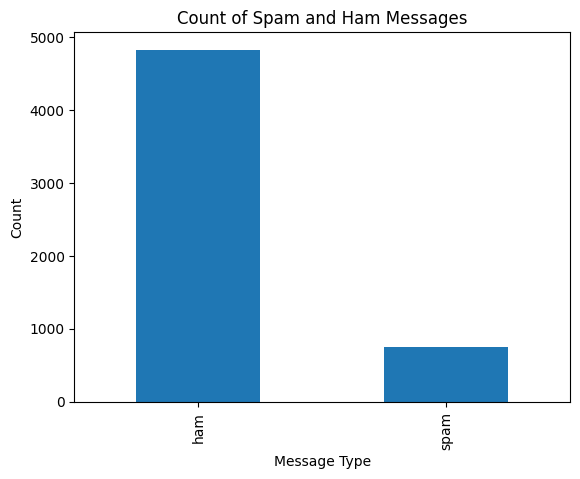

In [40]:
# count the number of spam and ham
df['label'].value_counts().plot(kind='bar')

plt.title('Count of Spam and Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

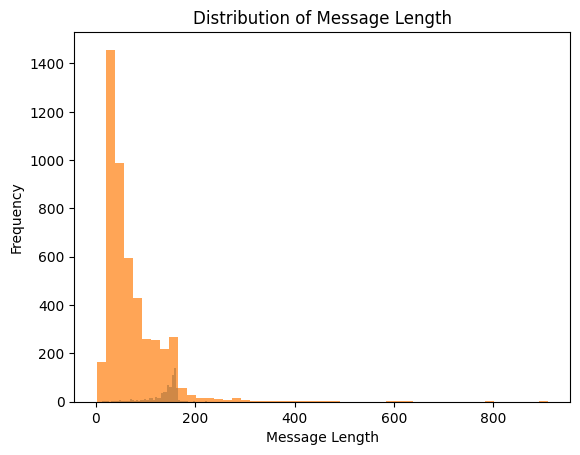

In [41]:
#creat a length column
df['length'] = df['text'].apply(len)
#draw a histogram
plt.hist(df[df['label']=='spam']['length'], bins=50, alpha=0.7, label='spam')
plt.hist(df[df['label']=='ham']['length'], bins=50, alpha=0.7, label='ham')

plt.title('Distribution of Message Length')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend
plt.show()

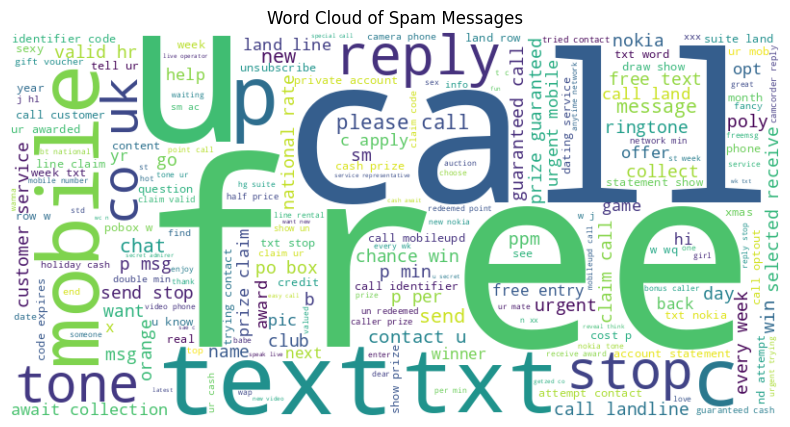

In [42]:
#merge all spam texts
spam_text = ' '.join(df[df['label']=='spam']['clean_text'])

#generate a word cloud(spam)
spam_wc = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Spam Messages')
plt.show()

In [43]:
print(df.head())
print(df['label'].value_counts())

  label                                               text  \
0   ham  Go until jurong point, crazy.. Available only ...   
1   ham                      Ok lar... Joking wif u oni...   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3   ham  U dun say so early hor... U c already then say...   
4   ham  Nah I don't think he goes to usf, he lives aro...   

                                          clean_text  label_num  length  
0  go jurong point crazy available bugis n great ...          0     111  
1                            ok lar joking wif u oni          0      29  
2  free entry wkly comp win fa cup final tkts st ...          1     155  
3                u dun say early hor u c already say          0      49  
4                nah think go usf life around though          0      61  
label
ham     4825
spam     747
Name: count, dtype: int64


## **Phase 3 & 4: Model Selection and Evaluation**
We train a Multinomial Naive Bayes model using TF-IDF features and evaluate its performance using a confusion matrix and classification report.

Accuracy: 0.9632

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.73      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



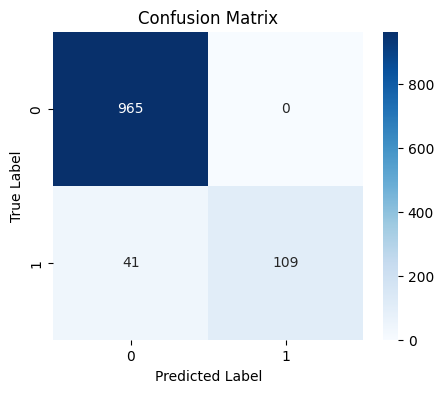

In [44]:
# 1. 数据拆分 [cite: 17]
X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], df['label_num'], test_size=0.2, random_state=42)

# 2. 特征提取 (TF-IDF) [cite: 15]
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 3. 模型训练 [cite: 17]
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 4. 评估指标 [cite: 18, 50]
y_pred = model.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 混淆矩阵热图 [cite: 18, 50]
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## **Real-time System Demonstration**
This section allows us to input new, unseen messages to test the model's predictive power in a real-world scenario.

In [45]:
# --- 交互式预测部分 (Interactive Prediction) ---

def predict_spam(new_message):
    # 1. 预处理输入的文本 (使用之前定义的 clean_text 函数)
    cleaned_msg = clean_text(new_message)

    # 2. 将文本转换为 TF-IDF 向量 (使用训练好的 tfidf 实例)
    # 注意：这里必须用 .transform() 而不是 .fit_transform()
    vectorized_msg = tfidf.transform([cleaned_msg])

    # 3. 使用模型进行预测
    prediction = model.predict(vectorized_msg)

    # 4. 获取预测概率 (可选，增加演示深度)
    probability = model.predict_proba(vectorized_msg)

    # 5. 输出结果
    result = "🚨 垃圾邮件 (SPAM)" if prediction[0] == 1 else "✅ 正常邮件 (HAM)"
    confidence = probability[0][prediction[0]] * 100

    print(f"\n邮件内容: {new_message}")
    print(f"预测结果: {result}")
    print(f"置信度: {confidence:.2f}%")

# --- 演示示例 ---
# 你可以在演示时修改这里的文字
test_msg = "CONGRATULATIONS! You have won a 1000 dollar gift card. Call 123456 to claim now!"
predict_spam(test_msg)

# 也可以尝试一个正常的
test_msg_2 = "Hey, are we still meeting for coffee at 3pm?"
predict_spam(test_msg_2)


邮件内容: CONGRATULATIONS! You have won a 1000 dollar gift card. Call 123456 to claim now!
预测结果: 🚨 垃圾邮件 (SPAM)
置信度: 56.88%

邮件内容: Hey, are we still meeting for coffee at 3pm?
预测结果: ✅ 正常邮件 (HAM)
置信度: 99.10%
